# Deteccao de fraudes em cartoes de credito
### Analise exploratoria e comparacao de modelos

Este notebook trabalha com o dataset Credit Card Fraud Detection do Kaggle

A base reune transacoes de cartoes europeus realizadas em setembro de 2013 e tem uma caracteristica: as fraudes sao muito raras em relacao ao total


## 1. Configuracao do ambiente

In [3]:
#Dados
import pandas as pd
import numpy as np

#Visualizacao
import matplotlib.pyplot as plt
import seaborn as sns

#Modelos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#Metricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
)
from imblearn.over_sampling import SMOTE


import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Ambiente configurado.")

Ambiente configurado.


## 2. Carregamento dos dados


In [4]:
DATA_PATH = "creditcard.csv"
USANDO_DADOS_SINTETICOS = False

try:
    df = pd.read_csv(DATA_PATH)
    print(f"Dataset original carregado de '{DATA_PATH}'.")
except FileNotFoundError:
    print(f"Arquivo '{DATA_PATH}' nao encontrado.")
    print("Gerando uma base sintetica apenas para testar o fluxo do notebook...\n")
    df = gerar_dataset_sintetico(random_state=RANDOM_STATE)
    USANDO_DADOS_SINTETICOS = True
    print("Base sintetica gerada.")

print(f"\nFormato do dataset: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
df.head()

Dataset original carregado de 'creditcard.csv'.

Formato do dataset: 17,918 linhas x 31 colunas


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


## 3. Exploracao inicial dos dados


In [5]:
print("=" * 60)
print("INFORMACOES GERAIS")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("VALORES NULOS POR COLUNA")
print("=" * 60)
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "Nenhum valor nulo encontrado.")

print("\n" + "=" * 60)
print("LINHAS DUPLICADAS")
print("=" * 60)
print(f"Total de duplicadas: {df.duplicated().sum():,}")

INFORMACOES GERAIS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17918 entries, 0 to 17917
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    17918 non-null  int64  
 1   V1      17918 non-null  float64
 2   V2      17918 non-null  float64
 3   V3      17918 non-null  float64
 4   V4      17918 non-null  float64
 5   V5      17917 non-null  float64
 6   V6      17917 non-null  float64
 7   V7      17917 non-null  float64
 8   V8      17917 non-null  float64
 9   V9      17917 non-null  float64
 10  V10     17917 non-null  float64
 11  V11     17917 non-null  float64
 12  V12     17917 non-null  float64
 13  V13     17917 non-null  float64
 14  V14     17917 non-null  float64
 15  V15     17917 non-null  float64
 16  V16     17917 non-null  float64
 17  V17     17917 non-null  float64
 18  V18     17917 non-null  float64
 19  V19     17917 non-null  float64
 20  V20     17917 non-null  float64
 21  V21     17917 no

### 3.1 Tratamento de valores nulos
Como identificamos valores nulos em Amount e Class, vamos remover essas linhas para evitar erros no treinamento dos modelos

In [6]:
#Removendo linhas com valores nulos
df = df.dropna()

print(f"Valores nulos após a limpeza:\n{df.isnull().sum().sum()}")
print(f"Novo formato do dataset: {df.shape[0]:,} linhas")

Valores nulos após a limpeza:
0
Novo formato do dataset: 17,917 linhas


In [7]:
#Time e Amount sao as variaveis com interpretacao direta
#As colunas V1..V28 ficam resumidas, pois sao componentes PCA anonimizadas
print("Estatisticas de Time e Amount:")
display(df[["Time", "Amount"]].describe().T)

print("\nEstatisticas agregadas das componentes PCA (V1..V28):")
v_cols = [c for c in df.columns if c.startswith("V")]
display(df[v_cols].describe().T[["mean", "std", "min", "max"]].describe())

Estatisticas de Time e Amount:


,count,mean,std,min,25%,50%,75%,max
Time,17917.0,13904.432048,9867.544555,0.0,3781.00,12346.00,23772.00,29030.00
Amount,17917.0,67.504000,189.184677,0.0,5.49,15.95,56.67,7712.43



Estatisticas agregadas das componentes PCA (V1..V28):


,mean,std,min,max
count,28.000000,28.000000,28.000000,28.000000
mean,0.085825,1.056839,-14.641924,10.815572
std,0.406809,0.440868,10.983568,8.813761
min,-1.223824,0.248679,-40.978852,1.960497
25%,-0.074392,0.628599,-23.530661,4.422972
50%,0.013740,1.191950,-11.847812,7.973292
75%,0.266521,1.345054,-5.112629,13.856450
max,0.780359,1.893189,-1.338556,34.303177


## 4. Desbalanceamento das classes



In [8]:
contagem = df["Class"].value_counts().sort_index()
percentual = df["Class"].value_counts(normalize=True).sort_index() * 100

resumo = pd.DataFrame({
    "Classe": ["Legitima (0)", "Fraude (1)"],
    "Quantidade": contagem.values,
    "Percentual (%)": percentual.values.round(4),
})
display(resumo)

razao = contagem[0] / contagem[1]
print(f"\nPara cada fraude, ha aproximadamente {razao:,.0f} transacoes legitimas.")

,Classe,Quantidade,Percentual (%)
0,Legitima (0),17836,99.5479
1,Fraude (1),81,0.4521



Para cada fraude, ha aproximadamente 220 transacoes legitimas.


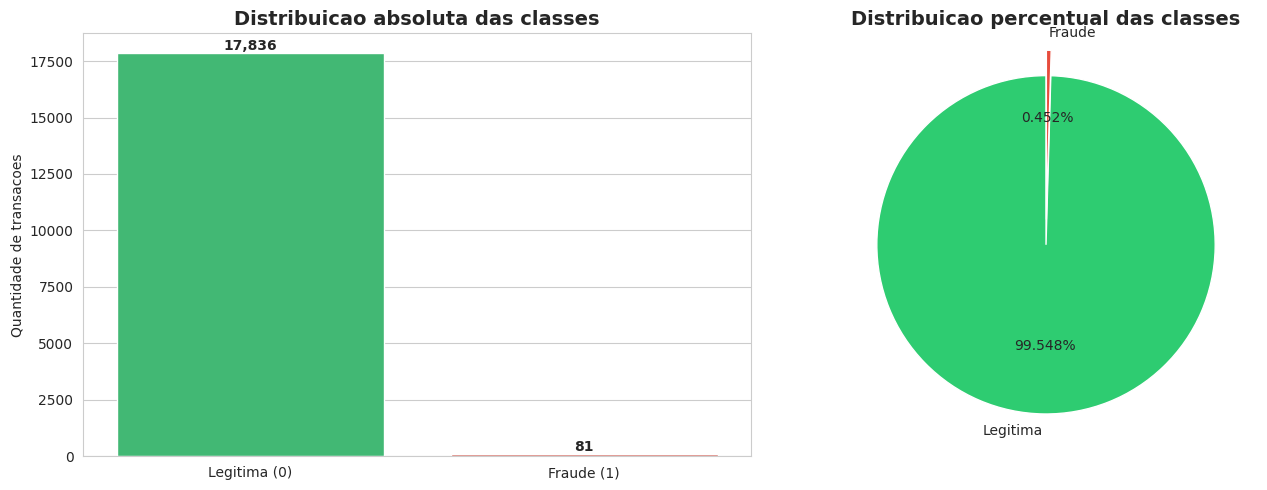

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Quantidade por classe
sns.barplot(x=["Legitima (0)", "Fraude (1)"], y=contagem.values,
            palette=["#2ecc71", "#e74c3c"], ax=axes[0])
axes[0].set_title("Distribuicao absoluta das classes")
axes[0].set_ylabel("Quantidade de transacoes")
for i, v in enumerate(contagem.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")

#Percentual por classe
axes[1].pie(
    percentual.values,
    labels=["Legitima", "Fraude"],
    autopct="%1.3f%%",
    colors=["#2ecc71", "#e74c3c"],
    explode=(0, 0.15),
    startangle=90,
)
axes[1].set_title("Distribuicao percentual das classes")

plt.tight_layout()
plt.show()

A visualizacao deixa a proporcao entre as classes mais concreta

A classe de fraude e pequena demais para ser avaliada por acuracia simples, entao as proximas etapas usam metricas mais adequadas para classe rara

## 5. Analise de Time e Amount


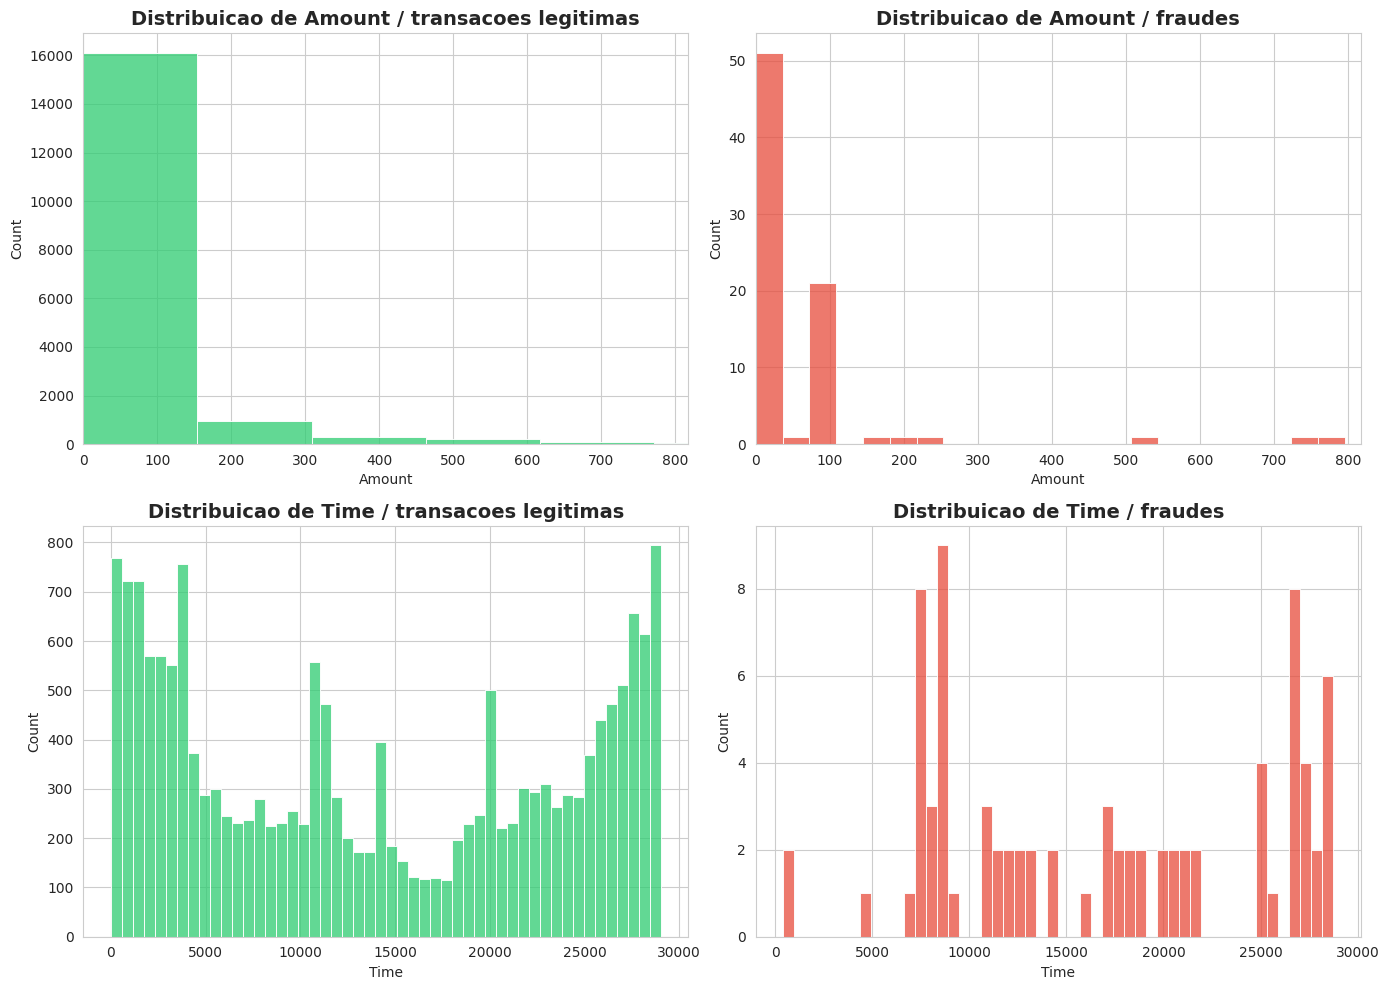

Estatisticas de Amount por classe:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0.0,17836.0,67.365025,188.754429,0.0,5.49,15.95,56.2325,7712.43
1.0,81.0,98.105926,267.464067,0.0,1.00,1.00,99.9900,1809.68


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#Distribuicao de Amount
sns.histplot(df[df["Class"] == 0]["Amount"], bins=50, color="#2ecc71",
             ax=axes[0, 0], kde=False)
axes[0, 0].set_title("Distribuicao de Amount / transacoes legitimas")
axes[0, 0].set_xlim(0, df["Amount"].quantile(0.99))

sns.histplot(df[df["Class"] == 1]["Amount"], bins=50, color="#e74c3c",
             ax=axes[0, 1], kde=False)
axes[0, 1].set_title("Distribuicao de Amount / fraudes")
axes[0, 1].set_xlim(0, df["Amount"].quantile(0.99))

#Distribuicao de Time
sns.histplot(df[df["Class"] == 0]["Time"], bins=50, color="#2ecc71", ax=axes[1, 0])
axes[1, 0].set_title("Distribuicao de Time / transacoes legitimas")

sns.histplot(df[df["Class"] == 1]["Time"], bins=50, color="#e74c3c", ax=axes[1, 1])
axes[1, 1].set_title("Distribuicao de Time / fraudes")

plt.tight_layout()
plt.show()

print("Estatisticas de Amount por classe:")
display(df.groupby("Class")["Amount"].describe())

O Amount pode indicar diferencas uteis entre as classes, principalmente quando ha concentracao de fraudes em faixas especificas de valor

O Time, sozinho, tende a ser menos conclusivo, mas ainda pode contribuir quando combinado com as demais variaveis

## 6. Correlacoes entre variaveis e classe

As variaveis V1 a V28 sao componentes geradas por PCA, entao a correlacao entre elas tende a ser baixa

O que mais interessa aqui e a correlacao de cada variavel com Class, pois isso da uma primeira nocao de quais componentes ajudam a separar fraude de transacao legitima

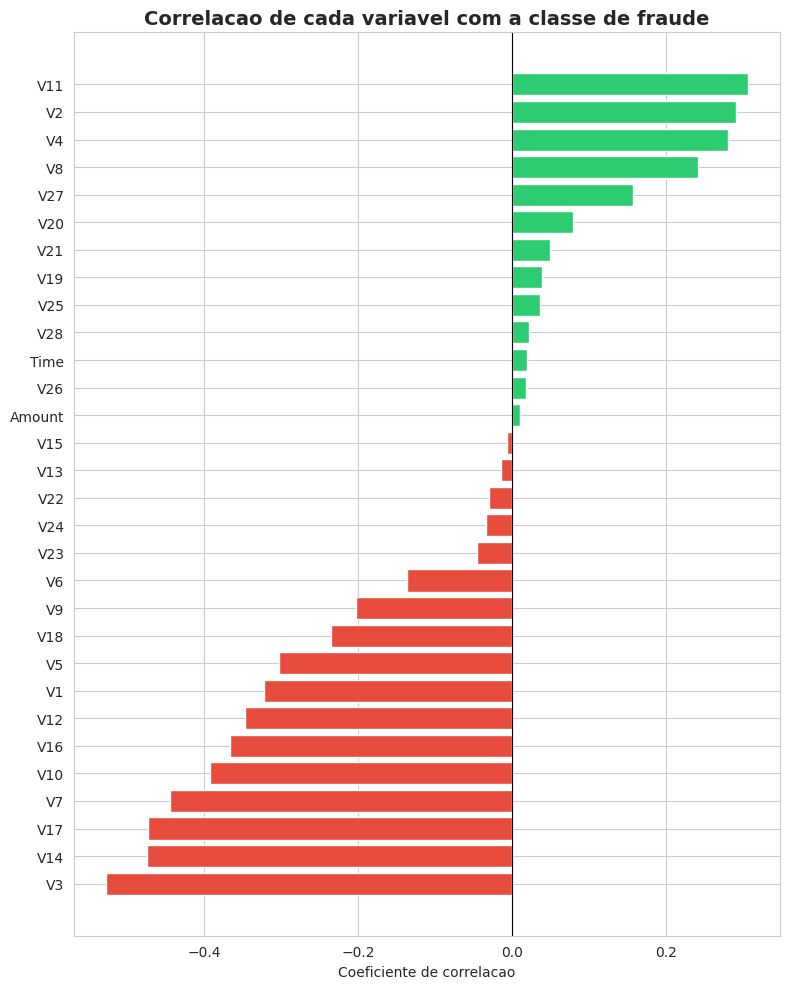

Top 5 correlacoes positivas com fraude:
V11    0.306639
V2     0.291367
V4     0.280571
V8     0.241125
V27    0.156947
Name: Class, dtype: float64

Top 5 correlacoes negativas com fraude:
V3    -0.527513
V14   -0.474621
V17   -0.473324
V7    -0.445011
V10   -0.393023
Name: Class, dtype: float64


In [11]:
corr_com_classe = df.corr()["Class"].drop("Class").sort_values()

plt.figure(figsize=(8, 10))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in corr_com_classe.values]
plt.barh(corr_com_classe.index, corr_com_classe.values, color=colors)
plt.title("Correlacao de cada variavel com a classe de fraude")
plt.xlabel("Coeficiente de correlacao")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print("Top 5 correlacoes positivas com fraude:")
print(corr_com_classe.sort_values(ascending=False).head(5))
print("\nTop 5 correlacoes negativas com fraude:")
print(corr_com_classe.sort_values().head(5))

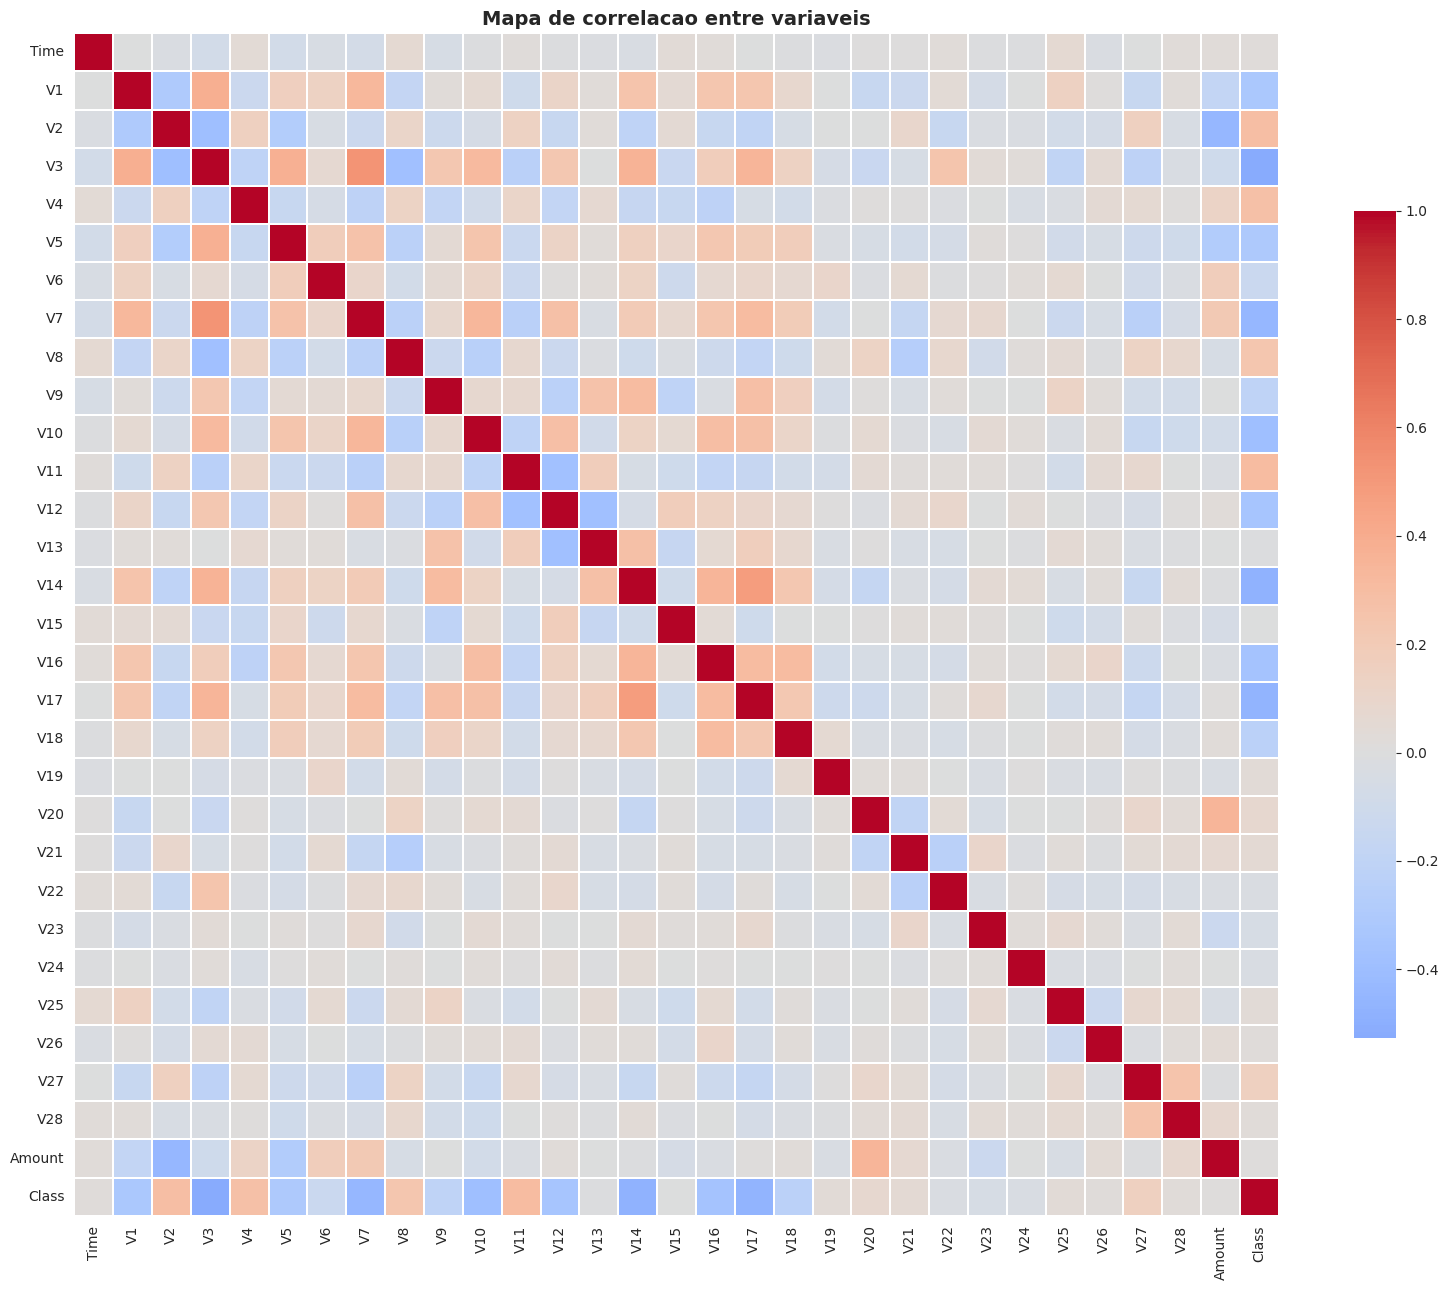

In [12]:
#O heatmap serve como uma conferencia geral das correlacoes da base.
plt.figure(figsize=(16, 13))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, linewidths=0.2, cbar_kws={"shrink": 0.7})
plt.title("Mapa de correlacao entre variaveis")
plt.tight_layout()
plt.show()

Como esperado, as componentes tem pouca correlacao entre si

Ainda assim, algumas delas apresentam associacao maior com Class e podem ter peso relevante nos modelos

## 7. Pre-processamento

As colunas V1..V28 ja vem transformadas pelo PCA

Ja Time e Amount estao em escalas bem diferentes, entao aplico RobustScaler nelas

Essa escolha e util porque Amount costuma ter valores extremos, e o RobustScaler e menos sensivel a outliers do que uma padronizacao comum

In [13]:
scaler = RobustScaler()

df_proc = df.copy()
df_proc[["Time", "Amount"]] = scaler.fit_transform(df_proc[["Time", "Amount"]])

print("Antes do scaling:")
display(df[["Time", "Amount"]].describe().loc[["mean", "std", "min", "max"]])

print("\nDepois do scaling (RobustScaler):")
display(df_proc[["Time", "Amount"]].describe().loc[["mean", "std", "min", "max"]])

Antes do scaling:


,Time,Amount
mean,13904.432048,67.504000
std,9867.544555,189.184677
min,0.000000,0.000000
max,29030.000000,7712.430000



Depois do scaling (RobustScaler):


,Time,Amount
mean,0.077957,1.007308
std,0.493599,3.696457
min,-0.617578,-0.311645
max,0.834576,150.380617


## 8. Separacao entre treino e teste

Como a classe de fraude e muito pequena, a divisao entre treino e teste precisa preservar a proporcao das classes

Por isso uso stratify=y no train_test_split

In [14]:
X = df_proc.drop(columns=["Class"])
y = df_proc["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Treino: {X_train.shape[0]:,} amostras | Fraudes: {y_train.sum():,} ({y_train.mean()*100:.4f}%)")
print(f"Teste : {X_test.shape[0]:,} amostras | Fraudes: {y_test.sum():,} ({y_test.mean()*100:.4f}%)")

Treino: 14,333 amostras | Fraudes: 65.0 (0.4535%)
Teste : 3,584 amostras | Fraudes: 16.0 (0.4464%)


## 9. Estrategias para lidar com o desbalanceamento

Neste notebook comparo duas abordagens simples:

1. class_weight="balanced": o proprio algoritmo aumenta o peso da classe minoritaria durante o treinamento
2. SMOTE: cria exemplos sinteticos da classe minoritaria, usando apenas o conjunto de treino

O ponto principal e nao aplicar oversampling antes da divisao treino/teste

Se isso fosse feito, informacoes do treino poderiam contaminar o teste e deixar as metricas artificialmente boas

In [15]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Distribuicao da classe antes do SMOTE (somente treino):")
print(y_train.value_counts())
print("\nDistribuicao da classe depois do SMOTE (somente treino):")
print(y_train_smote.value_counts())


Distribuicao da classe antes do SMOTE (somente treino):
Class
0.0    14268
1.0       65
Name: count, dtype: int64

Distribuicao da classe depois do SMOTE (somente treino):
Class
0.0    14268
1.0    14268
Name: count, dtype: int64


## 10. Baseline com Regressao Logistica

A Regressao Logistica entra como modelo de referencia

Ela eh simples, rapida de treinar e ajuda a entender se modelos mais complexos realmente trazem ganho

In [16]:
log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE,
)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("Relatorio de classificacao / Regressao Logistica (baseline):")
print(classification_report(y_test, y_pred_lr, target_names=["Legitima", "Fraude"], digits=4))

Relatorio de classificacao / Regressao Logistica (baseline):
              precision    recall  f1-score   support

    Legitima     1.0000    0.9865    0.9932      3568
      Fraude     0.2500    1.0000    0.4000        16

    accuracy                         0.9866      3584
   macro avg     0.6250    0.9933    0.6966      3584
weighted avg     0.9967    0.9866    0.9906      3584



A matriz de confusao mostra os acertos e erros por classe

Para este problema, e especialmente importante observar os falsos negativos, que sao fraudes classificadas como transacoes legitimas

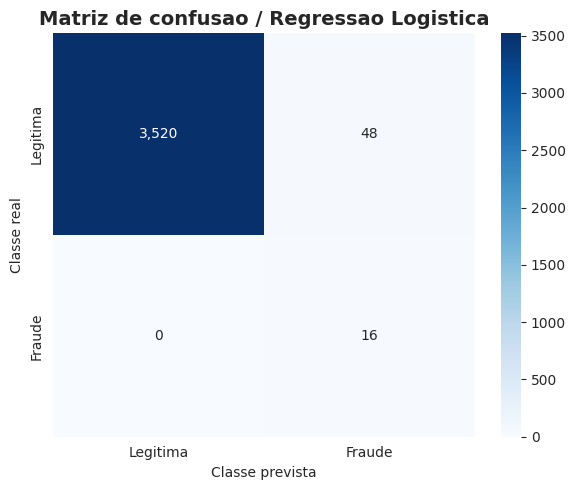

In [17]:
def plotar_matriz_confusao(y_true, y_pred, titulo):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt=",d", cmap="Blues",
        xticklabels=["Legitima", "Fraude"],
        yticklabels=["Legitima", "Fraude"],
    )
    plt.title(titulo)
    plt.ylabel("Classe real")
    plt.xlabel("Classe prevista")
    plt.tight_layout()
    plt.show()

plotar_matriz_confusao(y_test, y_pred_lr, "Matriz de confusao / Regressao Logistica")

Em bases muito desbalanceadas, a curva Precision-Recall costuma ser mais informativa que a curva ROC

A ROC pode parecer boa mesmo quando o modelo ainda tem dificuldade com a classe rara

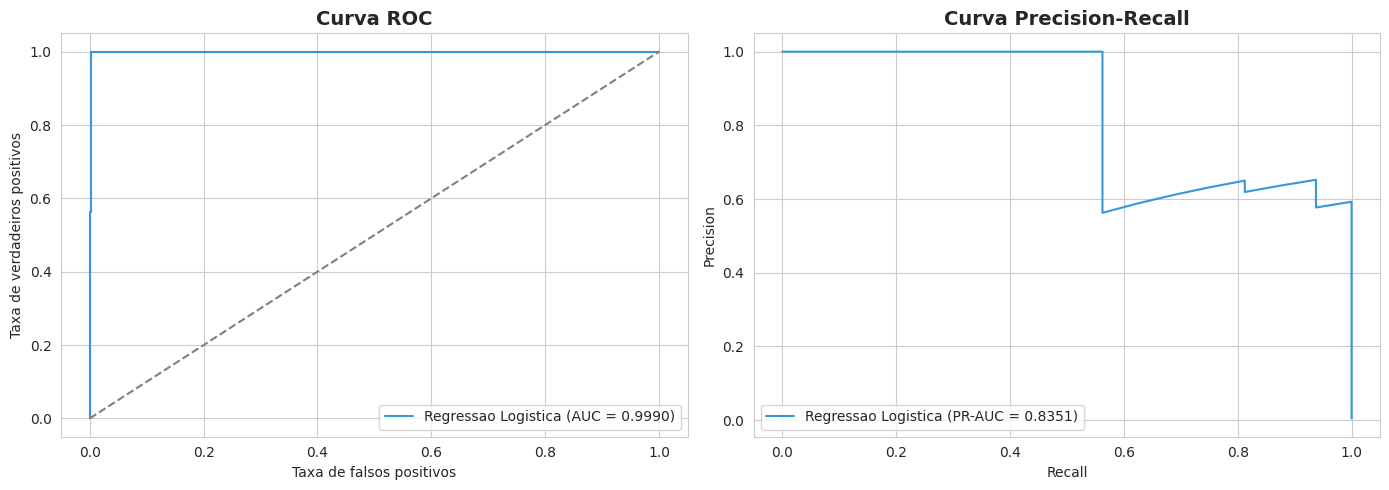

In [18]:
def plotar_curvas(y_true, y_proba, nome_modelo, cor):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc_roc = roc_auc_score(y_true, y_proba)
    axes[0].plot(fpr, tpr, color=cor, label=f"{nome_modelo} (AUC = {auc_roc:.4f})")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_title("Curva ROC")
    axes[0].set_xlabel("Taxa de falsos positivos")
    axes[0].set_ylabel("Taxa de verdadeiros positivos")
    axes[0].legend()

    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    auprc = average_precision_score(y_true, y_proba)
    axes[1].plot(recall, precision, color=cor, label=f"{nome_modelo} (PR-AUC = {auprc:.4f})")
    axes[1].set_title("Curva Precision-Recall")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return auc_roc, auprc

auc_roc_lr, auprc_lr = plotar_curvas(y_test, y_proba_lr, "Regressao Logistica", "#3498db")

## 11. Random Forest

Tambem treino uma Random Forest, que consegue capturar relacoes nao lineares e interacoes entre variaveis

Foram testadas duas versoes:

- Random Forest com class_weight="balanced";
- Random Forest treinada com a base balanceada por SMOTE.

A comparacao entre as duas ajuda a verificar se o oversampling trouxe ganho neste caso

Relatorio de classificacao / Random Forest (class_weight balanceado):
              precision    recall  f1-score   support

    Legitima     0.9997    0.9994    0.9996      3568
      Fraude     0.8824    0.9375    0.9091        16

    accuracy                         0.9992      3584
   macro avg     0.9410    0.9685    0.9543      3584
weighted avg     0.9992    0.9992    0.9992      3584



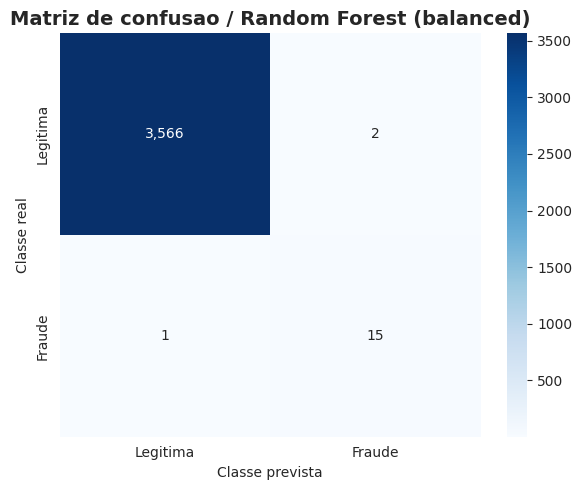

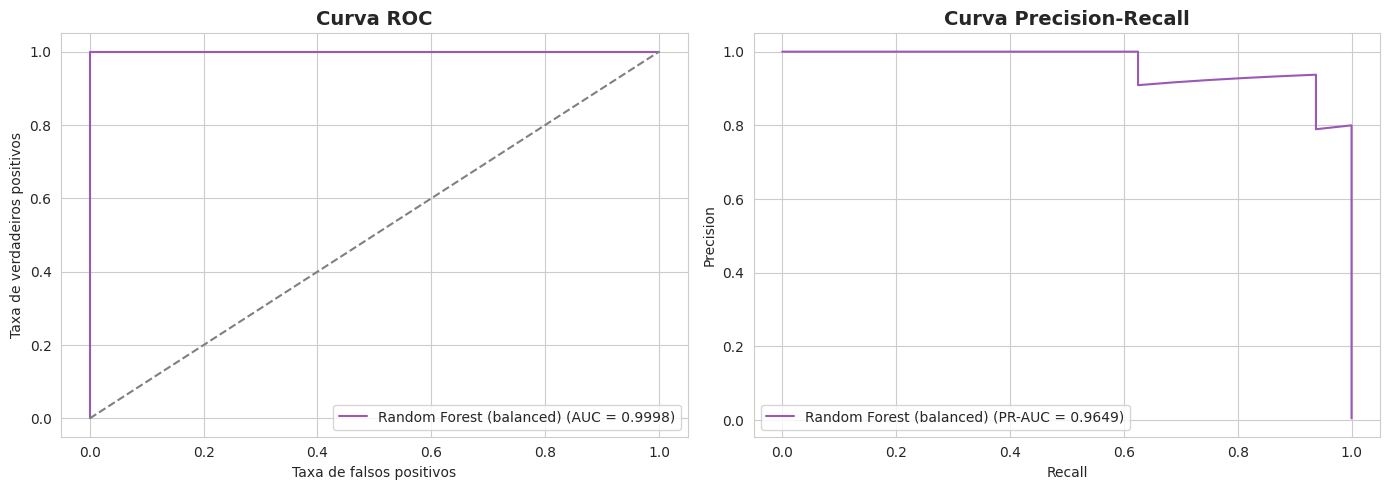

In [19]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_balanced.fit(X_train, y_train)

y_pred_rf = rf_balanced.predict(X_test)
y_proba_rf = rf_balanced.predict_proba(X_test)[:, 1]

print("Relatorio de classificacao / Random Forest (class_weight balanceado):")
print(classification_report(y_test, y_pred_rf, target_names=["Legitima", "Fraude"], digits=4))

plotar_matriz_confusao(y_test, y_pred_rf, "Matriz de confusao / Random Forest (balanced)")
auc_roc_rf, auprc_rf = plotar_curvas(y_test, y_proba_rf, "Random Forest (balanced)", "#9b59b6")

Relatorio de classificacao / Random Forest + SMOTE:
              precision    recall  f1-score   support

    Legitima     1.0000    0.9989    0.9994      3568
      Fraude     0.8000    1.0000    0.8889        16

    accuracy                         0.9989      3584
   macro avg     0.9000    0.9994    0.9442      3584
weighted avg     0.9991    0.9989    0.9989      3584



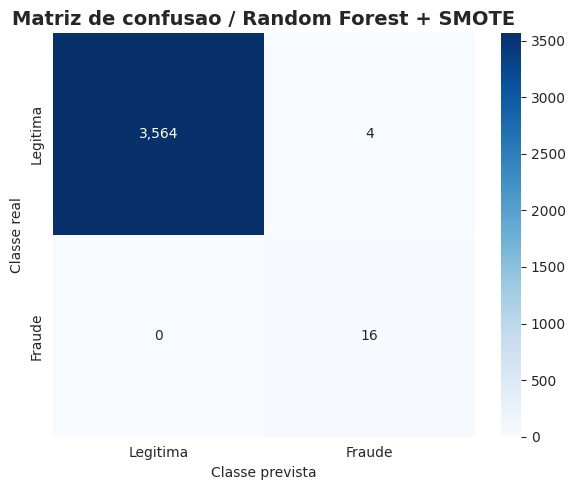

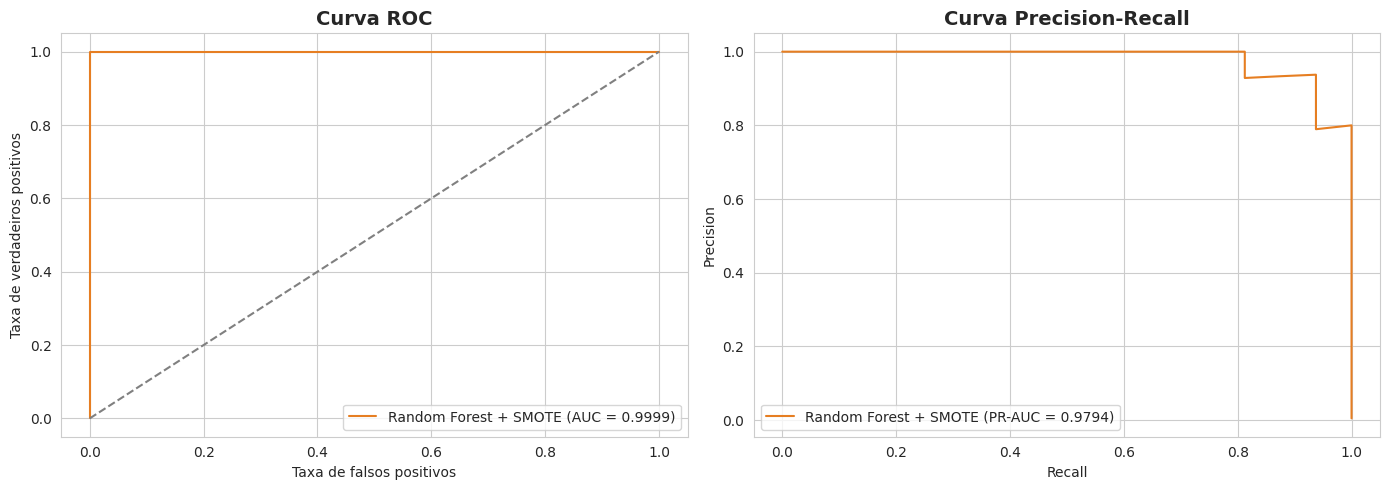

In [20]:
rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote.predict(X_test)
y_proba_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

print("Relatorio de classificacao / Random Forest + SMOTE:")
print(classification_report(y_test, y_pred_rf_smote, target_names=["Legitima", "Fraude"], digits=4))

plotar_matriz_confusao(y_test, y_pred_rf_smote, "Matriz de confusao / Random Forest + SMOTE")
auc_roc_rf_smote, auprc_rf_smote = plotar_curvas(y_test, y_proba_rf_smote, "Random Forest + SMOTE", "#e67e22")

## 12. Comparacao dos modelos

Aqui reuno as principais metricas em uma tabela unica

A ordenacao usa PR-AUC, porque ela resume melhor o desempenho do modelo na classe rara do que a acuracia ou mesmo o ROC-AUC

In [21]:
resultados = pd.DataFrame({
    "Modelo": [
        "Regressao Logistica (balanced)",
        "Random Forest (balanced)",
        "Random Forest + SMOTE",
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf_smote),
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf_smote),
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf_smote),
    ],
    "ROC-AUC": [auc_roc_lr, auc_roc_rf, auc_roc_rf_smote],
    "PR-AUC": [auprc_lr, auprc_rf, auprc_rf_smote],
})

resultados = resultados.sort_values("PR-AUC", ascending=False).reset_index(drop=True)
display(resultados.style.background_gradient(cmap="Greens", subset=["Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]))

,Modelo,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Random Forest + SMOTE,0.800000,1.000000,0.888889,0.999895,0.979427
1,Random Forest (balanced),0.882353,0.937500,0.909091,0.999842,0.964947
2,Regressao Logistica (balanced),0.250000,1.000000,0.400000,0.999037,0.835128


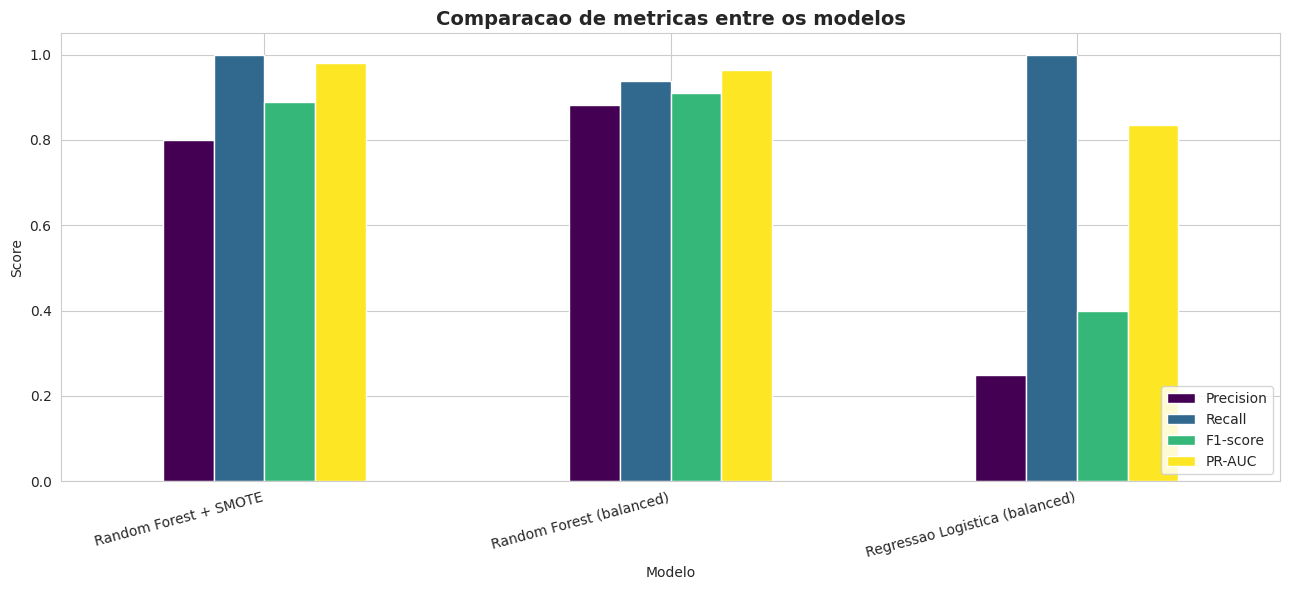

Melhor modelo por PR-AUC: Random Forest + SMOTE


In [22]:
metricas_plot = resultados.set_index("Modelo")[["Precision", "Recall", "F1-score", "PR-AUC"]]
metricas_plot.plot(kind="bar", figsize=(13, 6), colormap="viridis")
plt.title("Comparacao de metricas entre os modelos")
plt.ylabel("Score")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

melhor_modelo_nome = resultados.iloc[0]["Modelo"]
print(f"Melhor modelo por PR-AUC: {melhor_modelo_nome}")

Mesmo quando o ROC-AUC fica alto para mais de um modelo, a PR-AUC costuma mostrar melhor as diferencas na identificacao de fraudes

Por isso ela foi usada como criterio principal na comparacao

## 13. Ajuste do threshold de decisao

O classificador binario usa, por padrao, threshold de 0,5

Esse valor nao precisa ser fixo

Em problemas de fraude, ele deve ser ajustado conforme o custo de cada tipo de erro

- Threshold mais baixo: tende a aumentar o recall, mas tambem aumenta falsos positivos
- Threshold mais alto: tende a aumentar a precision, mas pode deixar mais fraudes passarem

Uso o F1-score como criterio simples para escolher um threshold de equilibrio

Threshold que maximiza o F1-score: 0.8500
Precision nesse ponto: 0.9375
Recall nesse ponto:    0.9375
F1-score nesse ponto:  0.9375


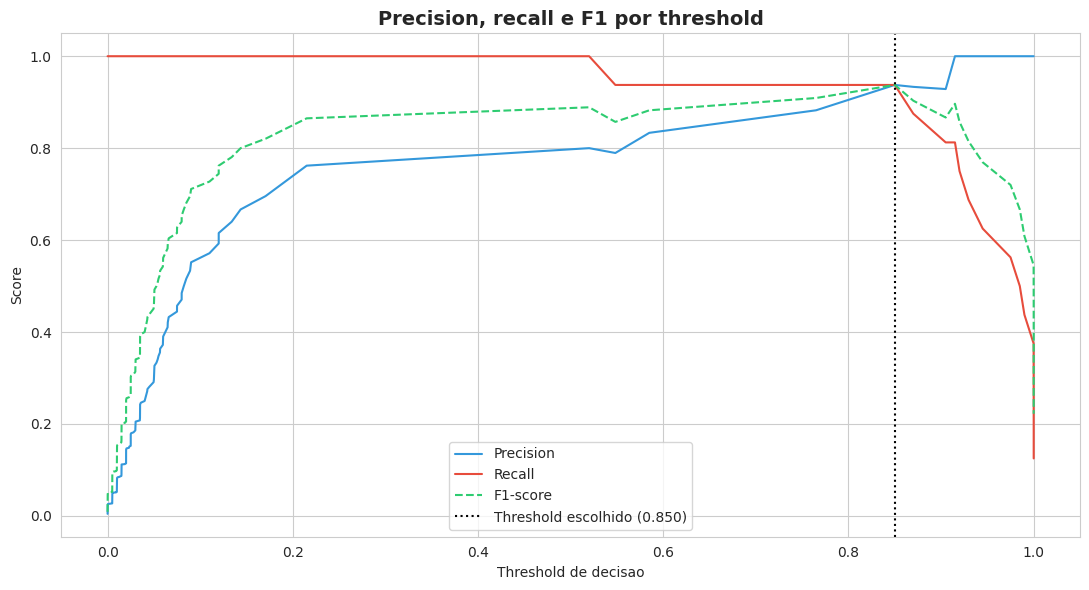

In [23]:
probabilidades_melhor_modelo = y_proba_rf_smote if "SMOTE" in melhor_modelo_nome else y_proba_rf

precisions, recalls, thresholds = precision_recall_curve(y_test, probabilidades_melhor_modelo)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-12)

idx_melhor_f1 = np.argmax(f1_scores)
melhor_threshold = thresholds[idx_melhor_f1] if idx_melhor_f1 < len(thresholds) else 0.5

print(f"Threshold que maximiza o F1-score: {melhor_threshold:.4f}")
print(f"Precision nesse ponto: {precisions[idx_melhor_f1]:.4f}")
print(f"Recall nesse ponto:    {recalls[idx_melhor_f1]:.4f}")
print(f"F1-score nesse ponto:  {f1_scores[idx_melhor_f1]:.4f}")

plt.figure(figsize=(11, 6))
plt.plot(thresholds, precisions[:-1], label="Precision", color="#3498db")
plt.plot(thresholds, recalls[:-1], label="Recall", color="#e74c3c")
plt.plot(thresholds, f1_scores[:-1], label="F1-score", color="#2ecc71", linestyle="--")
plt.axvline(melhor_threshold, color="black", linestyle=":", label=f"Threshold escolhido ({melhor_threshold:.3f})")
plt.xlabel("Threshold de decisao")
plt.ylabel("Score")
plt.title("Precision, recall e F1 por threshold")
plt.legend()
plt.tight_layout()
plt.show()

Relatorio de classificacao com threshold ajustado:
              precision    recall  f1-score   support

    Legitima     0.9997    0.9997    0.9997      3568
      Fraude     0.9375    0.9375    0.9375        16

    accuracy                         0.9994      3584
   macro avg     0.9686    0.9686    0.9686      3584
weighted avg     0.9994    0.9994    0.9994      3584



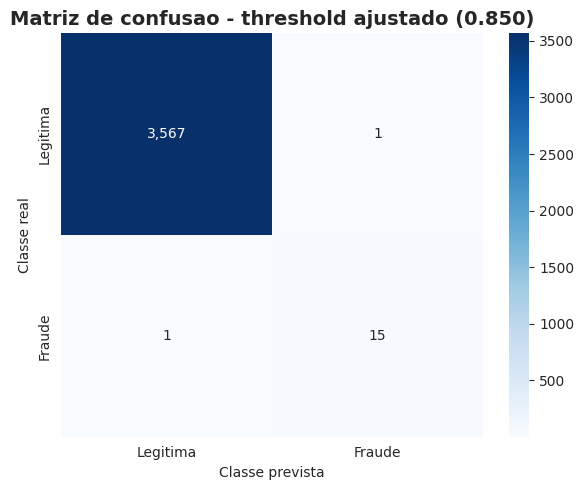

In [24]:
y_pred_threshold_ajustado = (probabilidades_melhor_modelo >= melhor_threshold).astype(int)

print("Relatorio de classificacao com threshold ajustado:")
print(classification_report(y_test, y_pred_threshold_ajustado, target_names=["Legitima", "Fraude"], digits=4))

plotar_matriz_confusao(y_test, y_pred_threshold_ajustado, f"Matriz de confusao - threshold ajustado ({melhor_threshold:.3f})")

## 14. Importancia das variaveis

Mesmo com variaveis anonimizadas, a Random Forest permite observar quais componentes tiveram maior peso nas decisoes do modelo

Isso nao explica diretamente o significado de cada variavel, mas ajuda a identificar quais componentes merecem atencao

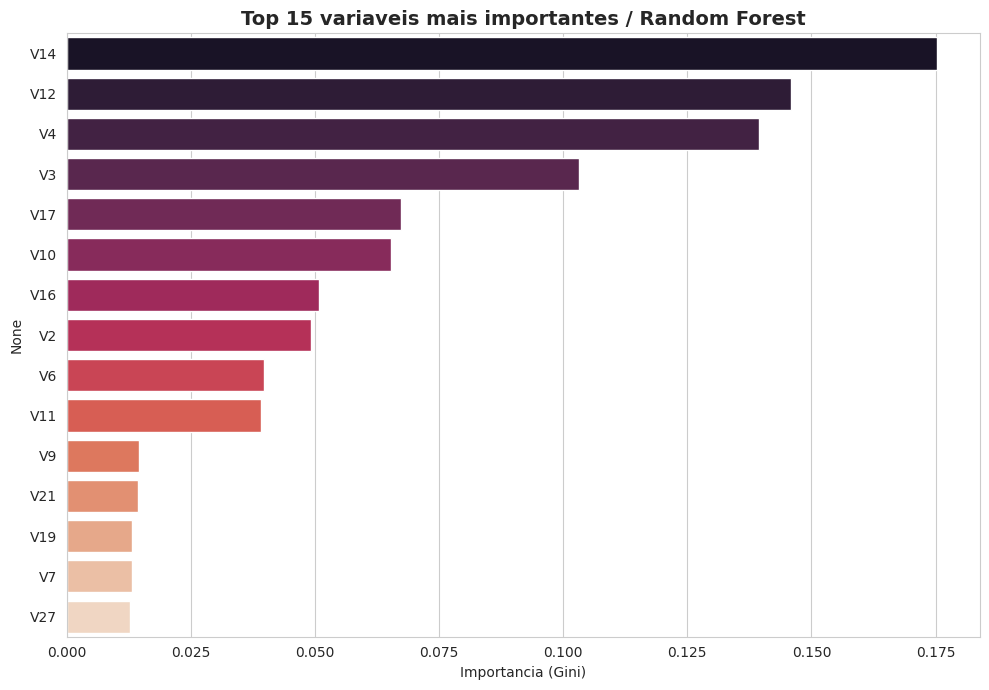

In [25]:
importancias = pd.Series(rf_balanced.feature_importances_, index=X_train.columns)
top_15 = importancias.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_15.values, y=top_15.index, palette="rocket")
plt.title("Top 15 variaveis mais importantes / Random Forest")
plt.xlabel("Importancia (Gini)")
plt.tight_layout()
plt.show()

## 15. Conclusoes

A base tem um desbalanceamento muito forte: as fraudes representam cerca de 0,17% das transacoes

Apesar disso o modelo de regressao foi bem na previsao de fraudes apesar de um numero elevado de falsos positivos gerando um f1-score menor que o modelo random forest

As metricas mais uteis aqui sao precision, recall, F1-score e principalmente PR-AUC

Entre os modelos testados, a comparacao por PR-AUC indica qual abordagem lidou melhor com a classe de fraude

A Regressao Logistica funcionou como referencia inicial, enquanto a Random Forest permitiu uma melhoria dos falsos positivos

O ajuste do threshold tambem e uma parte importante do problema

Em uma aplicacao real, essa escolha deveria considerar o custo de bloquear uma compra legitima e o custo de deixar passar uma fraude

Como esse custo nao foi informado, o F1-score foi usado como criterio de equilibrio


## Limitacoes

As variaveis V1..V28 sao componentes PCA anonimizadas

Isso protege informacoes sensiveis, mas reduz a interpretacao de negocio

Alem disso, a base original cobre apenas dois dias de transacoes de cartoes europeus em 2013, entao os resultados nao devem ser generalizados sem uma nova validacao

Dataset: [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)